## **CNN-Based Pneumonia Detection from Chest X-rays**

This project builds a **Convolutional Neural Network (CNN)** using TensorFlow/Keras to classify chest X-ray images into:

 1. Normal
 2. Pneumonia

The model helps demonstrate how deep learning can assist in **medical image diagnosis.**

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_path = "/content/drive/MyDrive/Archive.zip"

In [ ]:
import zipfile
import os

extract_path = "/content/Archive"

if not os.path.exists(extract_path):
    with zipfile.ZipFile("/content/drive/MyDrive/Archive (1).zip", 'r') as zip_ref:
        zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

['__MACOSX', 'val', 'train', 'test']


# **Data Preprocessing**

We apply data augmentation to improve generalization:
 1. Rotation
 2. Zoom
 3. Horizontal Flip
 4. Rescaling

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    "/content/Archive/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
    "/content/Archive/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


# **CNN Model Architecture**

The model contains:
 1. Conv2D layers (feature extraction)
 2. Batch Normalization
 3. MaxPooling layers
 4. Global Average Pooling
 5. Dense + Dropout
 6. Sigmoid output for binary classification

In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 455,361 (1.74 MB)

 Trainable params: 454,913 (1.74 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [ ]:
history = model.fit(
    train_data,
    epochs=20,
    validation_data=val_data,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9162 - loss: 0.2107
Epoch 1: val_loss did not improve from 2.35217
163/163 ━━━━━━━━━━━━━━━━━━━━ 1037s 6s/step - accuracy: 0.9155 - loss: 0.2114 - val_accuracy: 0.5000 - val_loss: 3.9360
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9298 - loss: 0.1842
Epoch 2: val_loss improved from 2.35217 to 0.58330, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1029s 6s/step - accuracy: 0.9229 - loss: 0.1953 - val_accuracy: 0.6250 - val_loss: 0.5833
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9265 - loss: 0.1874
Epoch 3: val_loss improved from 0.58330 to 0.58153, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1037s 6s/step - accuracy: 0.9281 - loss: 0.1850 - val_accuracy: 0.6250 - val_loss: 0.5815
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9351 - loss: 0.1703
Epoch 4: val_loss improved from 0.58153 to 0.43990, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1041s 6s/step - accuracy: 0.9375 - loss: 0.1673 - val_accuracy: 0.8750 - val_loss: 0.4399
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9329 - loss: 0.1640
Epoch 5: val_loss did not improve from 0.43990
163/163 ━━━━━━━━━━━━━━━━━━━━ 1020s 6s/step - accuracy: 0.9358 - loss: 0.1585 - val_accuracy: 0.5000 - val_loss: 1.6826
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9483 - loss: 0.1462
Epoch 6: val_loss did not improve from 0.43990
163/163 ━━━━━━━━━━━━━━━━━━━━ 1017s 6s/step - accuracy: 0.9408 - loss: 0.1534 - val_accuracy: 0.6875 - val_loss: 0.5798
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9418 - loss: 0.1494
Epoch 7: val_loss did not improve from 0.43990
163/163 ━━━━━━━━━━━━━━━━━━━━ 1036s 6s/step - accuracy: 0.9448 - loss: 0.1444 - val_accuracy: 0.5625 - val_loss: 1.9721
Epoch 7: early stopping
Restoring model weights from the end of the best epoch:

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)

test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    "/content/Archive/test",
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 624 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.models import load_model

model = load_model('best_model.h5')
model.evaluate(test_data)

20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.8157 - loss: 0.3927


[0.39272356033325195, 0.8157051205635071]

In [ ]:
predictions = model.predict(test_data)
y_pred = (predictions > 0.5).astype(int).flatten()
y_true = test_data.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step


In [ ]:
from sklearn.metrics import classification_report

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))


Classification Report:
              precision    recall  f1-score   support

      Normal       0.83      0.64      0.72       234
   Pneumonia       0.81      0.92      0.86       390

    accuracy                           0.82       624
   macro avg       0.82      0.78      0.79       624
weighted avg       0.82      0.82      0.81       624



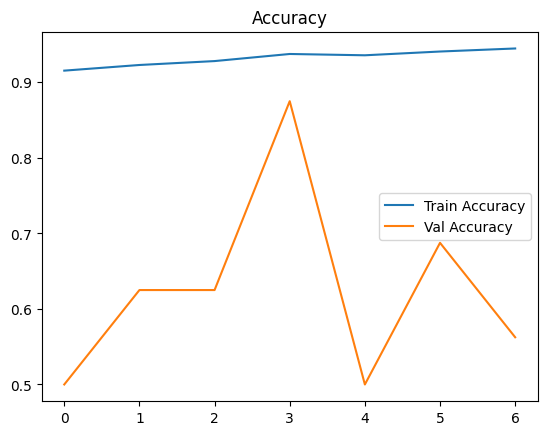

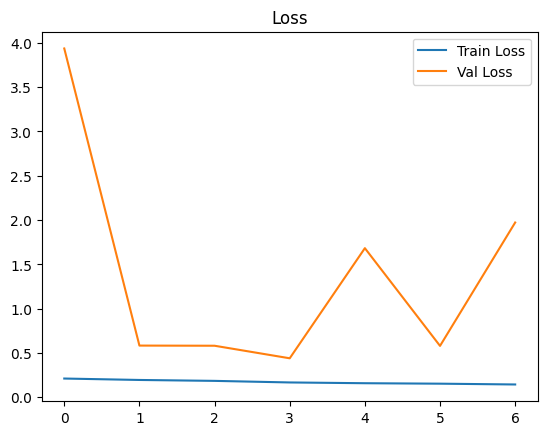

In [ ]:
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()

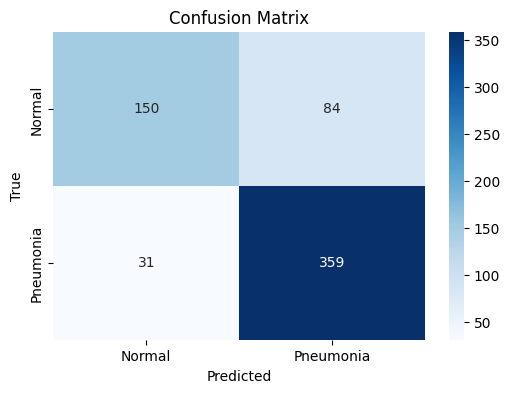

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Pneumonia'],
            yticklabels=['Normal','Pneumonia'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step


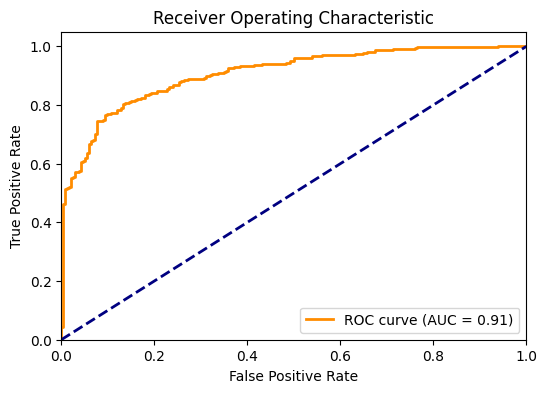

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict(test_data).ravel()

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step


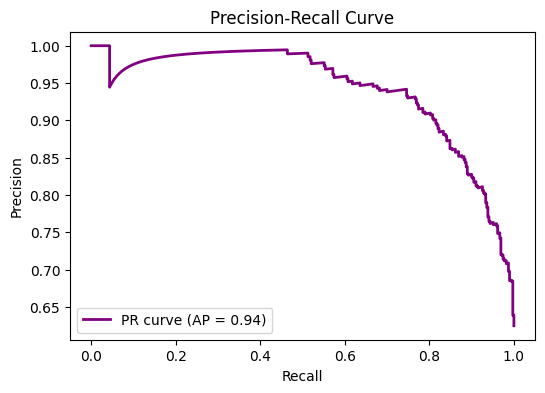

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

y_prob = model.predict(test_data).ravel()

precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
avg_precision = average_precision_score(y_true, y_prob)

plt.figure(figsize=(6,4))
plt.plot(recall, precision, color='purple', lw=2,
         label='PR curve (AP = %0.2f)' % avg_precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step


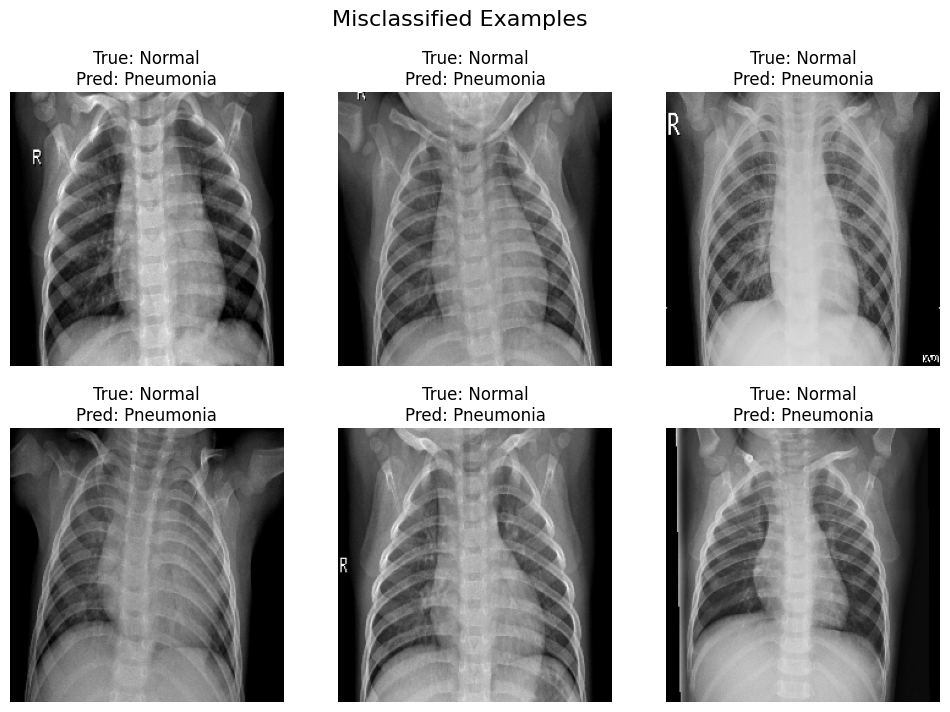

In [ ]:
import random

y_prob = model.predict(test_data).ravel()
y_pred = (y_prob > 0.5).astype(int)
y_true = test_data.classes
file_paths = test_data.filepaths

misclassified_idx = np.where(y_pred != y_true)[0]

sample_idx = random.sample(list(misclassified_idx), min(6, len(misclassified_idx)))

plt.figure(figsize=(12,8))
for i, idx in enumerate(sample_idx):
    img = tf.keras.preprocessing.image.load_img(file_paths[idx], target_size=(224,224))
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"True: {['Normal','Pneumonia'][y_true[idx]]}\nPred: {['Normal','Pneumonia'][y_pred[idx]]}")
plt.suptitle("Misclassified Examples", fontsize=16)
plt.show()